# Self-Supervised Representation Learning — Projet 4
## CNN vs ResNet-18 vs ViT-Tiny | SimCLR vs BYOL | STL-10

## CELLULE 1 — Imports

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import STL10
from torch.utils.data import DataLoader, TensorDataset, Subset
import timm
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

SAVE_DIR = '/content/SSL_Project'
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')
print(f'Dossier : {SAVE_DIR}')

Device  : cuda
Dossier : /content/SSL_Project


## CELLULE 2 — Dataset STL-10 (5000 images, 20 epochs)

In [2]:
class SimCLRAugmentation:
    def __init__(self, image_size=96):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.44671, 0.43981, 0.40664],
                                  std=[0.26033, 0.25642, 0.27099])
        ])
    def __call__(self, x):
        return self.transform(x), self.transform(x)

eval_transform = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.44671, 0.43981, 0.40664],
                          std=[0.26033, 0.25642, 0.27099])
])

unlabeled_dataset = STL10(root='./data', split='unlabeled', transform=SimCLRAugmentation(), download=True)
train_dataset     = STL10(root='./data', split='train',     transform=eval_transform, download=True)
test_dataset      = STL10(root='./data', split='test',      transform=eval_transform, download=True)

# 5000 images uniquement
indices       = np.random.choice(len(unlabeled_dataset), 5000, replace=False)
small_dataset = Subset(unlabeled_dataset, indices)

train_loader = DataLoader(small_dataset, batch_size=256, shuffle=True,  num_workers=0, drop_last=True, pin_memory=True)
probe_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=0)

print(f'Unlabeled reduit : {len(small_dataset)} images')
print(f'Train            : {len(train_dataset)} images')
print(f'Test             : {len(test_dataset)} images')
print('Dataset pret ✅')

100%|██████████| 2.64G/2.64G [00:38<00:00, 69.3MB/s]


Unlabeled reduit : 5000 images
Train            : 5000 images
Test             : 8000 images
Dataset pret ✅


## CELLULE 3 — Encodeurs

In [3]:
class CNNEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(128, out_dim)
    def forward(self, x):
        return self.fc(self.net(x).squeeze(-1).squeeze(-1))

class ResNet18Encoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        base = models.resnet18(weights=None)
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.fc = nn.Linear(512, out_dim)
    def forward(self, x):
        return self.fc(self.encoder(x).squeeze(-1).squeeze(-1))

class ViTTinyEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.vit = timm.create_model('vit_tiny_patch16_224', pretrained=False, num_classes=0, img_size=96)
        self.fc = nn.Linear(self.vit.num_features, out_dim)
    def forward(self, x):
        return self.fc(self.vit(x))

x = torch.randn(4, 3, 96, 96)
print('CNN     :', CNNEncoder()(x).shape)
print('ResNet  :', ResNet18Encoder()(x).shape)
print('ViT     :', ViTTinyEncoder()(x).shape)
print('Encodeurs OK ✅')

CNN     : torch.Size([4, 128])
ResNet  : torch.Size([4, 128])
ViT     : torch.Size([4, 128])
Encodeurs OK ✅


## CELLULE 4 — SimCLR

In [4]:
class ProjectionHead(nn.Module):
    def __init__(self, in_dim=128, hidden_dim=256, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, out_dim))
    def forward(self, x):
        return self.net(x)

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
    def forward(self, z1, z2):
        N = z1.shape[0]
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        z = torch.cat([z1, z2], dim=0)
        sim = torch.matmul(z, z.T) / self.temperature
        mask = torch.eye(2 * N, dtype=torch.bool).to(z.device)
        sim.masked_fill_(mask, float('-inf'))
        labels = torch.cat([torch.arange(N, 2*N), torch.arange(N)]).to(z.device)
        return F.cross_entropy(sim, labels)

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = ProjectionHead()
    def forward(self, x1, x2):
        return self.projector(self.encoder(x1)), self.projector(self.encoder(x2))

def train_simclr(encoder, train_loader, epochs=20, lr=3e-4, save_path=None):
    model     = SimCLR(encoder).to(device)
    criterion = NTXentLoss(temperature=0.5).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses    = []
    start_epoch = 0
    ckpt_path = save_path.replace('.pth', '_ckpt.pth') if save_path else None
    if ckpt_path and os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        start_epoch = ckpt['epoch']
        losses = ckpt['losses']
        print(f'Reprise depuis epoch {start_epoch} ✅')
    for epoch in range(start_epoch, epochs):
        model.train()
        total_loss = 0
        for (x1, x2), _ in train_loader:
            x1, x2 = x1.to(device), x2.to(device)
            z1, z2 = model(x1, x2)
            loss   = criterion(z1, z2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}')
        if ckpt_path:
            torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
                        'epoch': epoch+1, 'losses': losses}, ckpt_path)
    if save_path:
        torch.save(model.encoder.state_dict(), save_path)
        print(f'Modele sauvegarde ✅')
    return model.encoder, losses

print('SimCLR pret ✅')

SimCLR pret ✅


## CELLULE 5 — BYOL

In [5]:
class BYOLProjector(nn.Module):
    def __init__(self, in_dim=128, hidden_dim=256, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)

class BYOL(nn.Module):
    def __init__(self, encoder, tau=0.996):
        super().__init__()
        self.tau = tau
        self.online_encoder   = encoder
        self.online_projector = BYOLProjector()
        self.predictor        = BYOLProjector()
        self.target_encoder   = deepcopy(encoder)
        self.target_projector = deepcopy(self.online_projector)
        for p in self.target_encoder.parameters():   p.requires_grad = False
        for p in self.target_projector.parameters(): p.requires_grad = False

    def update_target(self):
        for po, pt in zip(self.online_encoder.parameters(), self.target_encoder.parameters()):
            pt.data = self.tau * pt.data + (1 - self.tau) * po.data
        for po, pt in zip(self.online_projector.parameters(), self.target_projector.parameters()):
            pt.data = self.tau * pt.data + (1 - self.tau) * po.data

    def forward(self, x1, x2):
        z1_online = self.online_projector(self.online_encoder(x1))
        z2_online = self.online_projector(self.online_encoder(x2))
        p1 = self.predictor(z1_online)
        p2 = self.predictor(z2_online)
        with torch.no_grad():
            z1_target = self.target_projector(self.target_encoder(x1))
            z2_target = self.target_projector(self.target_encoder(x2))
        return p1, p2, z1_target.detach(), z2_target.detach()

def byol_loss(p, z):
    return 2 - 2 * F.cosine_similarity(p, z, dim=-1).mean()

def train_byol(encoder, train_loader, epochs=20, lr=3e-4, save_path=None):
    model = BYOL(encoder).to(device)
    optimizer = optim.Adam(list(model.online_encoder.parameters()) +
                            list(model.online_projector.parameters()) +
                            list(model.predictor.parameters()), lr=lr)
    losses = []
    start_epoch = 0
    ckpt_path = save_path.replace('.pth', '_ckpt.pth') if save_path else None
    if ckpt_path and os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        start_epoch = ckpt['epoch']
        losses = ckpt['losses']
        print(f'Reprise depuis epoch {start_epoch} ✅')
    for epoch in range(start_epoch, epochs):
        model.train()
        total_loss = 0
        for (x1, x2), _ in train_loader:
            x1, x2 = x1.to(device), x2.to(device)
            p1, p2, z1, z2 = model(x1, x2)
            loss = byol_loss(p1, z2) + byol_loss(p2, z1)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            model.update_target()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}')
        if ckpt_path:
            torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
                        'epoch': epoch+1, 'losses': losses}, ckpt_path)
    if save_path:
        torch.save(model.online_encoder.state_dict(), save_path)
        print(f'Modele sauvegarde ✅')
    return model.online_encoder, losses

print('BYOL pret ✅')

BYOL pret ✅


## CELLULE 6 — Linear Probing

In [6]:
def linear_probing(encoder, probe_loader, test_loader, epochs=20, lr=1e-3):
    encoder.eval()
    def extract(loader):
        feats, labels = [], []
        with torch.no_grad():
            for x, y in loader:
                feats.append(encoder(x.to(device)).cpu())
                labels.append(y)
        return torch.cat(feats), torch.cat(labels)
    print('Extraction embeddings...')
    X_train, y_train = extract(probe_loader)
    X_test,  y_test  = extract(test_loader)
    classifier = nn.Linear(128, 10).to(device)
    optimizer  = optim.Adam(classifier.parameters(), lr=lr)
    criterion  = nn.CrossEntropyLoss()
    train_ds   = TensorDataset(X_train, y_train)
    train_dl   = DataLoader(train_ds, batch_size=256, shuffle=True)
    for epoch in range(epochs):
        classifier.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(classifier(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    classifier.eval()
    with torch.no_grad():
        preds = classifier(X_test.to(device)).argmax(dim=1).cpu()
        acc   = (preds == y_test).float().mean().item() * 100
    print(f'Top-1 Accuracy : {acc:.2f}%')
    return acc, X_test.numpy(), y_test.numpy()

print('Linear Probing pret ✅')

Linear Probing pret ✅


## CELLULE 7 — Visualisations t-SNE + UMAP

In [7]:
!pip install umap-learn -q
from sklearn.manifold import TSNE
import umap

CLASSES = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']
COLORS  = plt.cm.tab10.colors

def plot_tsne_umap_side_by_side(embeddings, labels, exp_name):
    print(f'Generation t-SNE + UMAP pour {exp_name}...')
    emb  = embeddings[:2000]
    lbls = labels[:2000]
    proj_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(emb)
    proj_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(emb)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, proj, method in zip(axes, [proj_tsne, proj_umap], ['t-SNE', 'UMAP']):
        for i in range(10):
            mask = lbls == i
            ax.scatter(proj[mask, 0], proj[mask, 1], s=5, label=CLASSES[i], alpha=0.7, color=COLORS[i])
        ax.set_title(f'{method} — {exp_name}')
        ax.legend(markerscale=3, bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/{exp_name.replace(" ","_")}_tsne_umap.png', dpi=150)
    plt.show()
    print('Sauvegarde ✅')

print('Visualisations pretes ✅')

Visualisations pretes ✅


## CELLULE 8 — Lancement E1 a E6 (20 epochs, 5000 images)

In [8]:
EPOCHS = 20

# E1 — CNN + SimCLR
path_e1    = f'{SAVE_DIR}/E1_cnn_simclr.pth'
encoder_e1 = CNNEncoder().to(device)
if os.path.exists(path_e1):
    encoder_e1.load_state_dict(torch.load(path_e1))
    print('E1 charge ✅')
else:
    print('--- Entrainement E1 — CNN + SimCLR ---')
    encoder_e1, _ = train_simclr(encoder_e1, train_loader, epochs=EPOCHS, save_path=path_e1)
print('Linear Probing E1 :')
acc_e1, emb_e1, lbl_e1 = linear_probing(encoder_e1, probe_loader, test_loader)

# E2 — ResNet-18 + SimCLR
path_e2    = f'{SAVE_DIR}/E2_resnet_simclr.pth'
encoder_e2 = ResNet18Encoder().to(device)
if os.path.exists(path_e2):
    encoder_e2.load_state_dict(torch.load(path_e2))
    print('E2 charge ✅')
else:
    print('--- Entrainement E2 — ResNet-18 + SimCLR ---')
    encoder_e2, _ = train_simclr(encoder_e2, train_loader, epochs=EPOCHS, save_path=path_e2)
print('Linear Probing E2 :')
acc_e2, emb_e2, lbl_e2 = linear_probing(encoder_e2, probe_loader, test_loader)

# E3 — ViT-Tiny + SimCLR
path_e3    = f'{SAVE_DIR}/E3_vit_simclr.pth'
encoder_e3 = ViTTinyEncoder().to(device)
if os.path.exists(path_e3):
    encoder_e3.load_state_dict(torch.load(path_e3))
    print('E3 charge ✅')
else:
    print('--- Entrainement E3 — ViT-Tiny + SimCLR ---')
    encoder_e3, _ = train_simclr(encoder_e3, train_loader, epochs=EPOCHS, save_path=path_e3)
print('Linear Probing E3 :')
acc_e3, emb_e3, lbl_e3 = linear_probing(encoder_e3, probe_loader, test_loader)

# E4 — CNN + BYOL
path_e4    = f'{SAVE_DIR}/E4_cnn_byol.pth'
encoder_e4 = CNNEncoder().to(device)
if os.path.exists(path_e4):
    encoder_e4.load_state_dict(torch.load(path_e4))
    print('E4 charge ✅')
else:
    print('--- Entrainement E4 — CNN + BYOL ---')
    encoder_e4, _ = train_byol(encoder_e4, train_loader, epochs=EPOCHS, save_path=path_e4)
print('Linear Probing E4 :')
acc_e4, emb_e4, lbl_e4 = linear_probing(encoder_e4, probe_loader, test_loader)

# E5 — ResNet-18 + BYOL
path_e5    = f'{SAVE_DIR}/E5_resnet_byol.pth'
encoder_e5 = ResNet18Encoder().to(device)
if os.path.exists(path_e5):
    encoder_e5.load_state_dict(torch.load(path_e5))
    print('E5 charge ✅')
else:
    print('--- Entrainement E5 — ResNet-18 + BYOL ---')
    encoder_e5, _ = train_byol(encoder_e5, train_loader, epochs=EPOCHS, save_path=path_e5)
print('Linear Probing E5 :')
acc_e5, emb_e5, lbl_e5 = linear_probing(encoder_e5, probe_loader, test_loader)

# E6 — ViT-Tiny + BYOL
path_e6    = f'{SAVE_DIR}/E6_vit_byol.pth'
encoder_e6 = ViTTinyEncoder().to(device)
if os.path.exists(path_e6):
    encoder_e6.load_state_dict(torch.load(path_e6))
    print('E6 charge ✅')
else:
    print('--- Entrainement E6 — ViT-Tiny + BYOL ---')
    encoder_e6, _ = train_byol(encoder_e6, train_loader, epochs=EPOCHS, save_path=path_e6)
print('Linear Probing E6 :')
acc_e6, emb_e6, lbl_e6 = linear_probing(encoder_e6, probe_loader, test_loader)

print('\n✅ Toutes les experiences terminees !')

--- Entrainement E1 — CNN + SimCLR ---
Epoch [1/20] Loss: 5.7616
Epoch [2/20] Loss: 5.4800
Epoch [3/20] Loss: 5.3773
Epoch [4/20] Loss: 5.3219
Epoch [5/20] Loss: 5.2394
Epoch [6/20] Loss: 5.2005
Epoch [7/20] Loss: 5.1846
Epoch [8/20] Loss: 5.1662
Epoch [9/20] Loss: 5.1437
Epoch [10/20] Loss: 5.1155
Epoch [11/20] Loss: 5.1029
Epoch [12/20] Loss: 5.0992
Epoch [13/20] Loss: 5.0815
Epoch [14/20] Loss: 5.0782
Epoch [15/20] Loss: 5.0715
Epoch [16/20] Loss: 5.0463
Epoch [17/20] Loss: 5.0418
Epoch [18/20] Loss: 5.0230
Epoch [19/20] Loss: 5.0069
Epoch [20/20] Loss: 5.0075
Modele sauvegarde ✅
Linear Probing E1 :
Extraction embeddings...
Top-1 Accuracy : 42.48%
--- Entrainement E2 — ResNet-18 + SimCLR ---
Epoch [1/20] Loss: 5.8418
Epoch [2/20] Loss: 5.4161
Epoch [3/20] Loss: 5.2834
Epoch [4/20] Loss: 5.1967
Epoch [5/20] Loss: 5.1305
Epoch [6/20] Loss: 5.0980
Epoch [7/20] Loss: 5.0840
Epoch [8/20] Loss: 5.0537
Epoch [9/20] Loss: 5.0324
Epoch [10/20] Loss: 5.0153
Epoch [11/20] Loss: 4.9816
Epoch [1

## CELLULE 9 — Resultats


   RESULTATS — Top-1 Accuracy (%)
  E2 ResNet+SimCLR       : 42.99%
  E1 CNN+SimCLR          : 42.48%
  E3 ViT+SimCLR          : 36.39%
  E4 CNN+BYOL            : 35.94%
  E5 ResNet+BYOL         : 24.74%
  E6 ViT+BYOL            : 24.42%


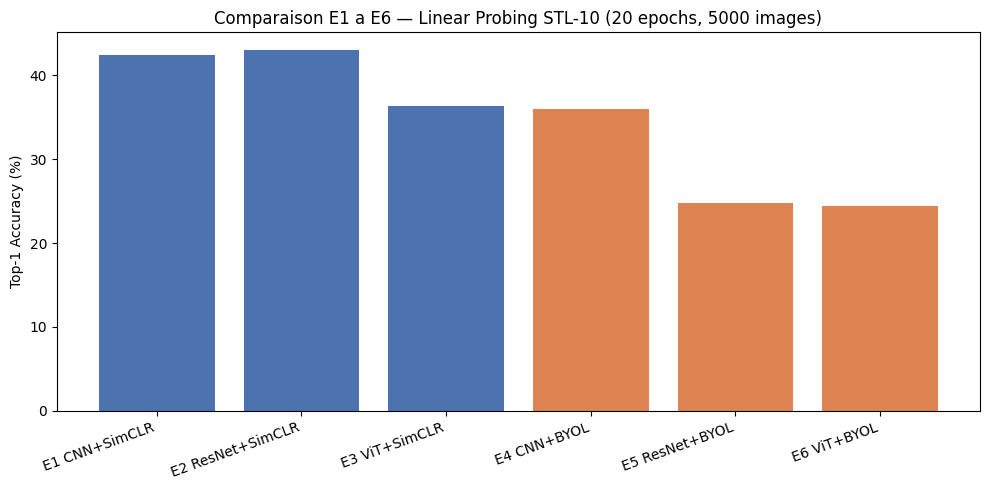

Graphique sauvegarde ✅


In [9]:
results = {
    'E1 CNN+SimCLR'    : acc_e1,
    'E2 ResNet+SimCLR' : acc_e2,
    'E3 ViT+SimCLR'    : acc_e3,
    'E4 CNN+BYOL'      : acc_e4,
    'E5 ResNet+BYOL'   : acc_e5,
    'E6 ViT+BYOL'      : acc_e6,
}

print('\n=======================================')
print('   RESULTATS — Top-1 Accuracy (%)')
print('=======================================')
for exp, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f'  {exp:<22} : {acc:.2f}%')
print('=======================================')

plt.figure(figsize=(10, 5))
colors = ['#4C72B0','#4C72B0','#4C72B0','#DD8452','#DD8452','#DD8452']
plt.bar(results.keys(), results.values(), color=colors)
plt.xticks(rotation=20, ha='right')
plt.ylabel('Top-1 Accuracy (%)')
plt.title('Comparaison E1 a E6 — Linear Probing STL-10 (20 epochs, 5000 images)')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/results.png', dpi=150)
plt.show()
print('Graphique sauvegarde ✅')

## CELLULE 10 — Visualisations t-SNE + UMAP

Generation t-SNE + UMAP pour E1 CNN SimCLR...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


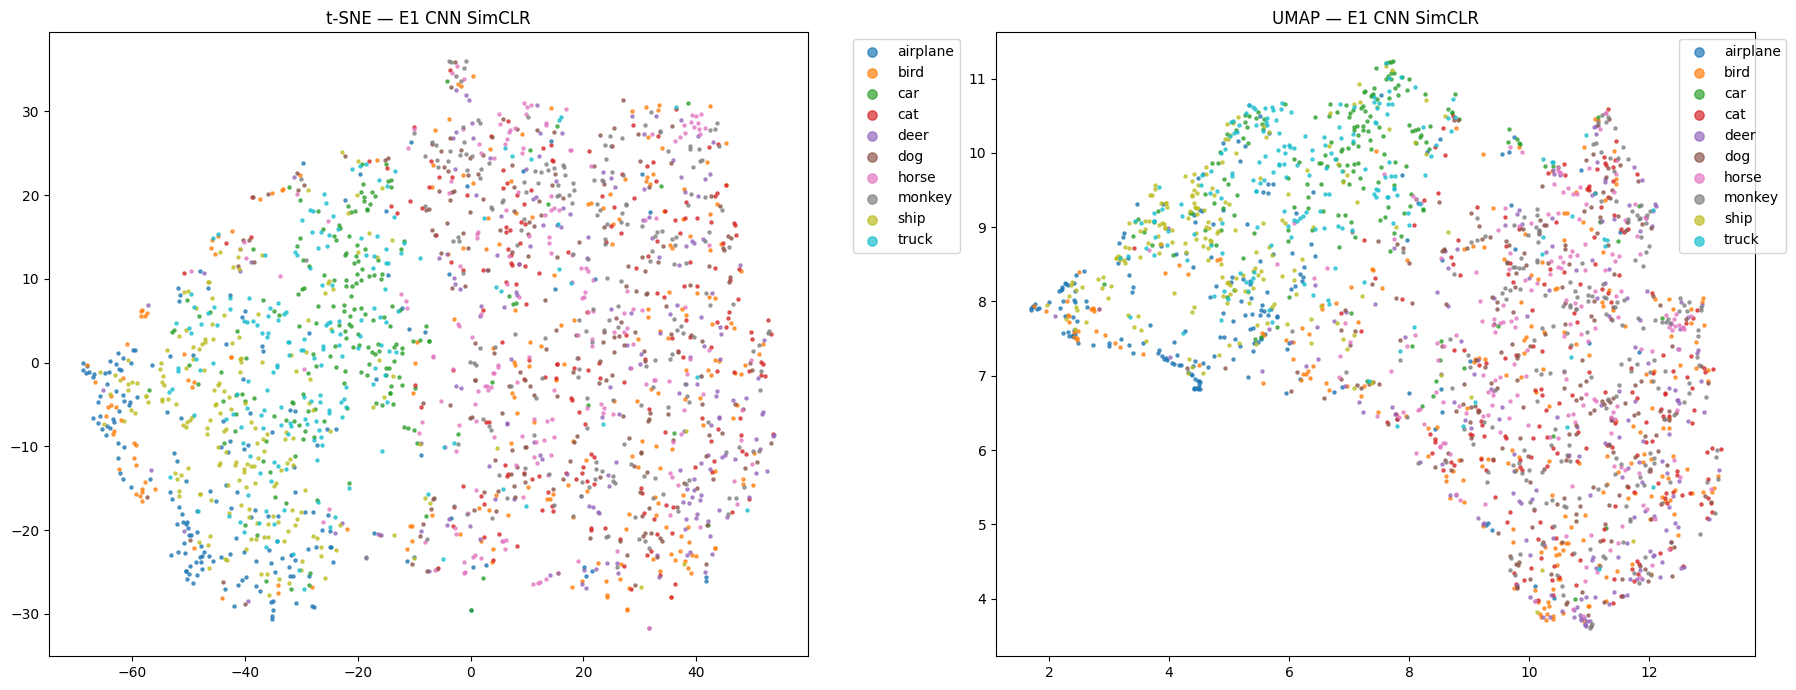

Sauvegarde ✅
Generation t-SNE + UMAP pour E2 ResNet SimCLR...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


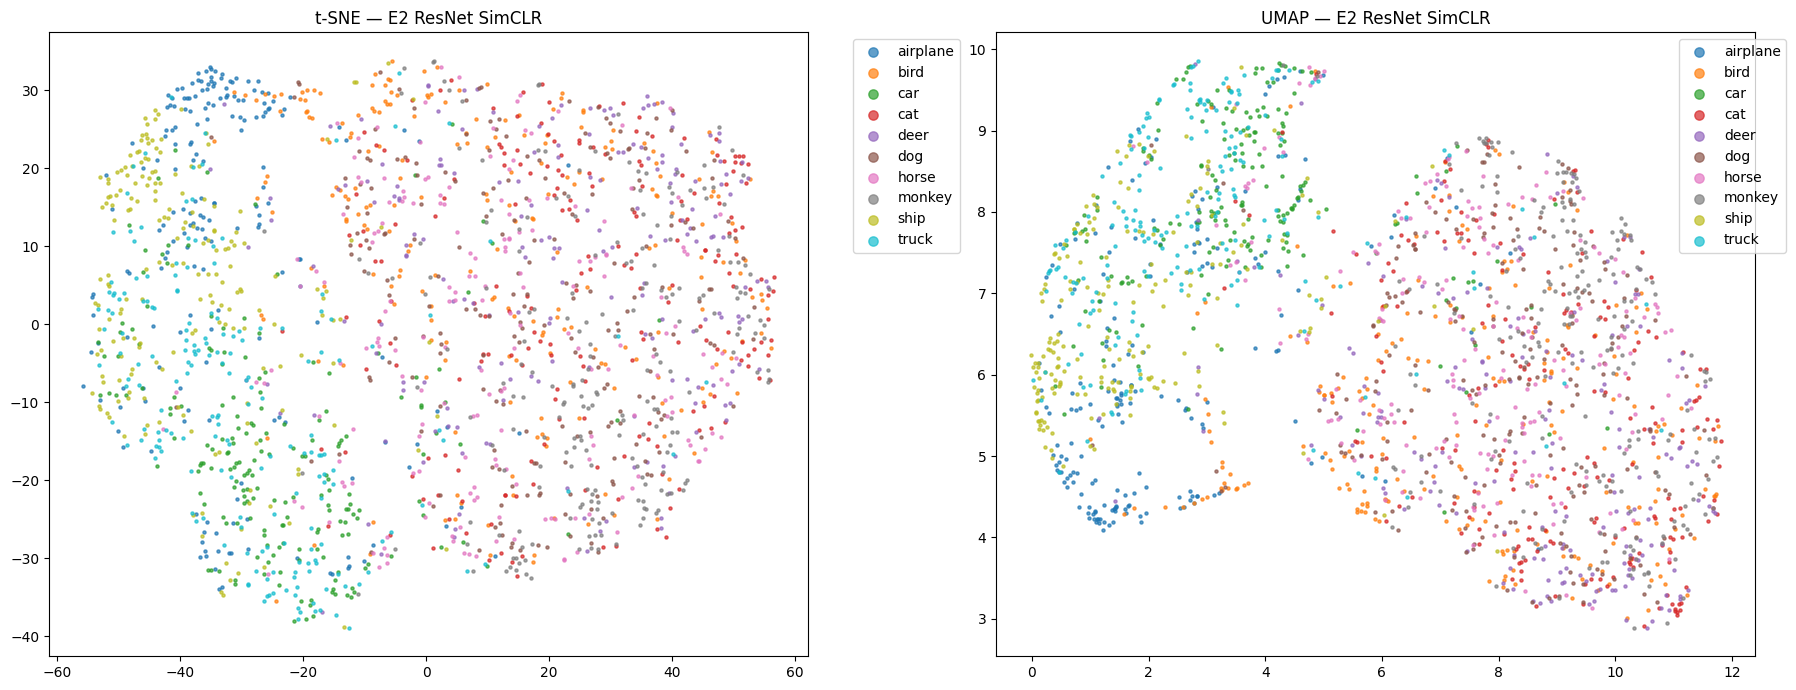

Sauvegarde ✅
Generation t-SNE + UMAP pour E3 ViT SimCLR...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


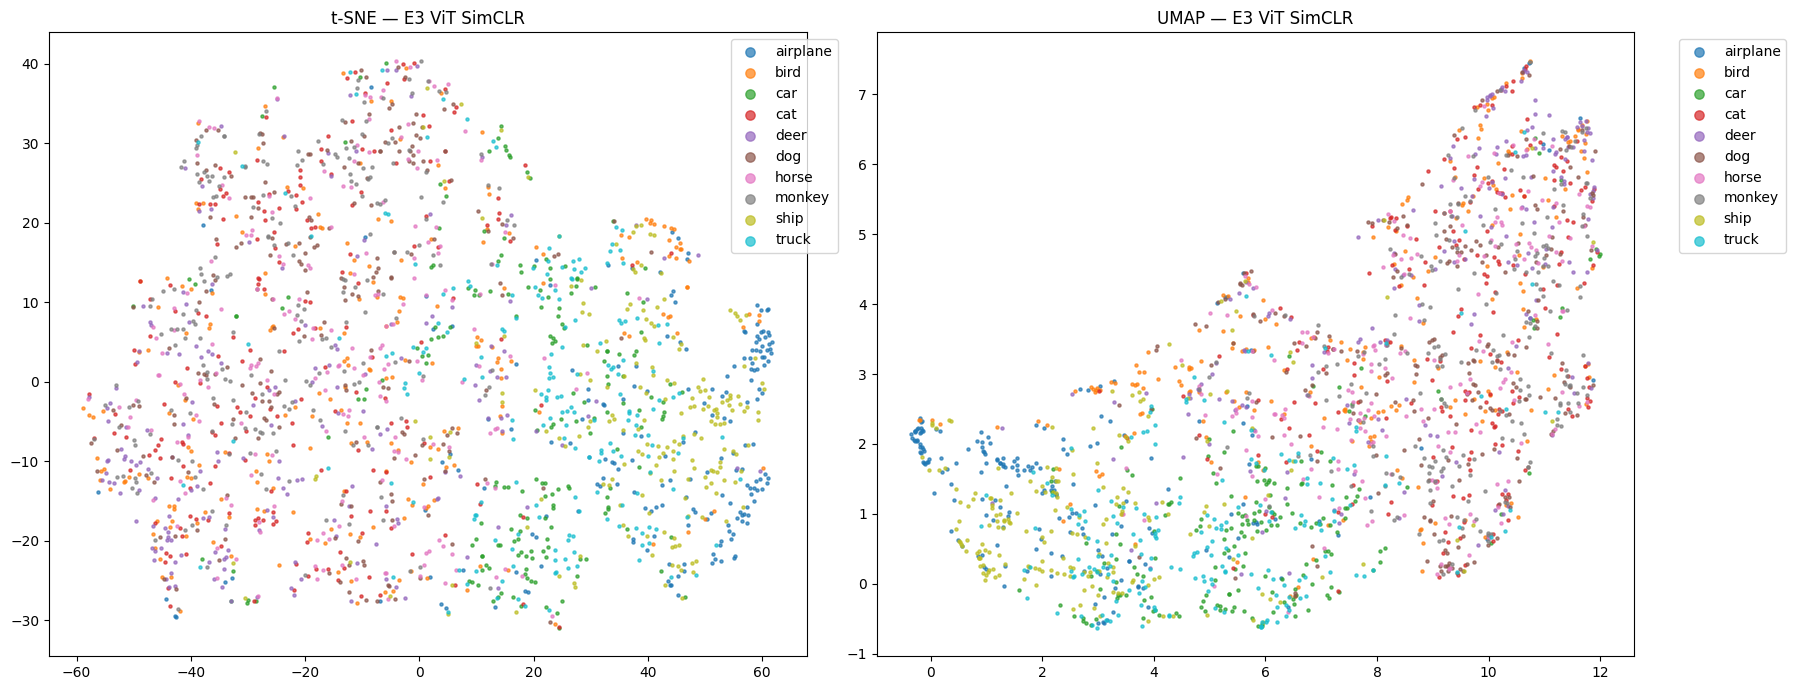

Sauvegarde ✅
Generation t-SNE + UMAP pour E4 CNN BYOL...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


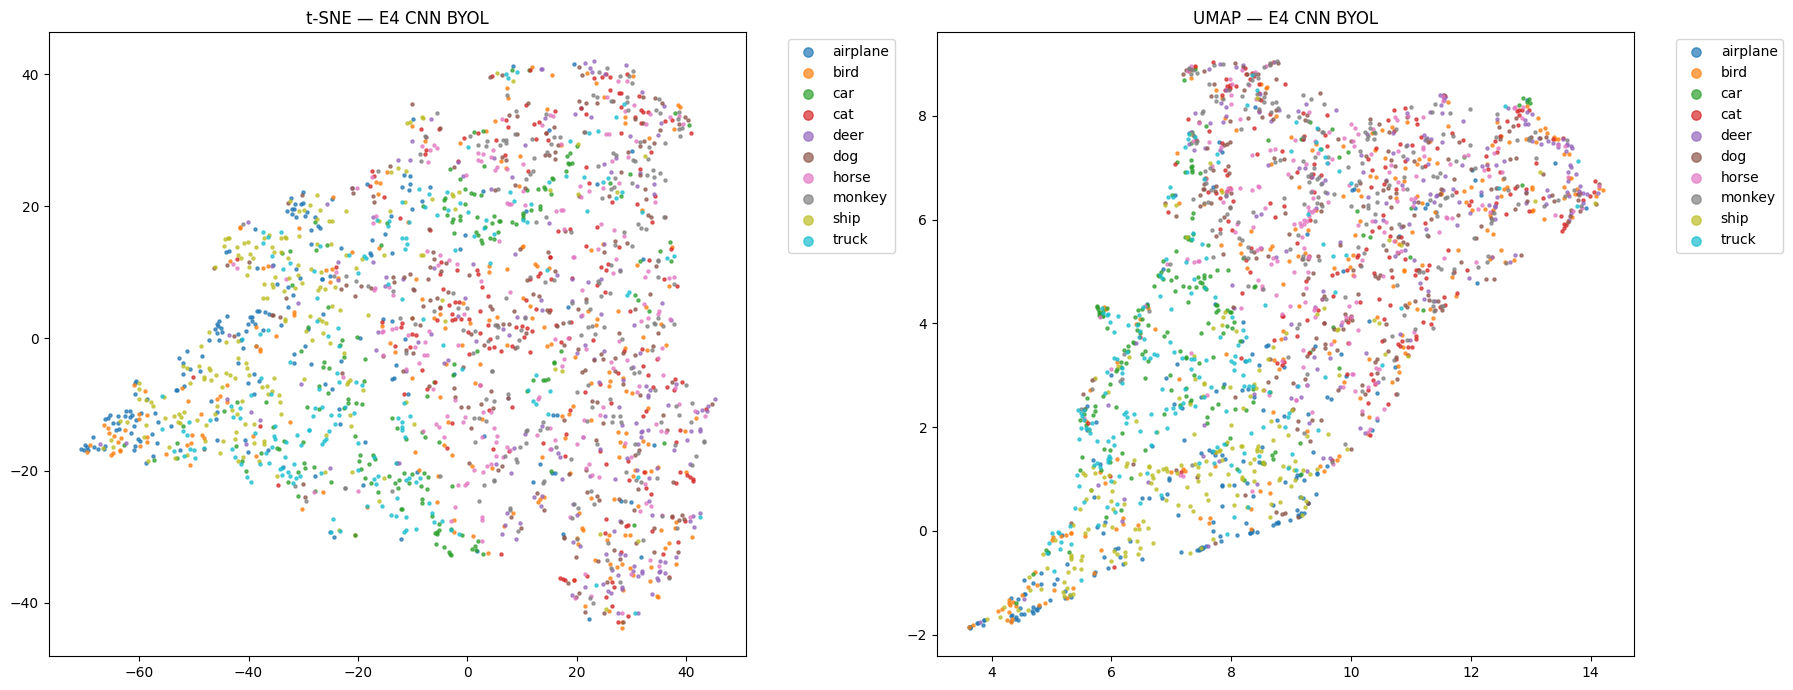

Sauvegarde ✅
Generation t-SNE + UMAP pour E5 ResNet BYOL...


In [ ]:
plot_tsne_umap_side_by_side(emb_e1, lbl_e1, 'E1 CNN SimCLR')
plot_tsne_umap_side_by_side(emb_e2, lbl_e2, 'E2 ResNet SimCLR')
plot_tsne_umap_side_by_side(emb_e3, lbl_e3, 'E3 ViT SimCLR')
plot_tsne_umap_side_by_side(emb_e4, lbl_e4, 'E4 CNN BYOL')
plot_tsne_umap_side_by_side(emb_e5, lbl_e5, 'E5 ResNet BYOL')
plot_tsne_umap_side_by_side(emb_e6, lbl_e6, 'E6 ViT BYOL')

## CELLULE 11 — Telecharger les resultats

In [ ]:
from google.colab import files
for fname in os.listdir(SAVE_DIR):
    fpath = f'{SAVE_DIR}/{fname}'
    files.download(fpath)
    print(f'Telecharge : {fname}')